In [1]:
import tensorflow as tf
from keras.utils import np_utils
from matplotlib import pyplot as plt
import numpy as np

In [2]:
import keras

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170508288/170498071 [==============================] - 363s 2us/step


In [4]:
print('Training Images: {}'.format(X_train.shape))
print('Testing Images: {}'.format(X_test.shape))

Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [6]:
print('Training Images: {}'.format(X_train.shape))
print('Testing Images: {}'.format(X_test.shape))

Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [7]:
print(X_train[0].shape)

(32, 32, 3)


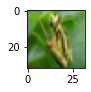

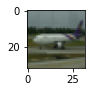

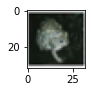

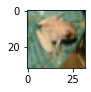

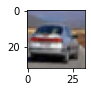

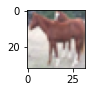

In [8]:
for i in range(232,238):
  plt.subplot(120+ 1 + i)
  img=X_train[i]
  plt.imshow(img)
  plt.show()

### PROCESSING THE DATA

In [9]:
from tensorflow.python.ops.variables import trainable_variables
X_train=X_train.reshape(X_train.shape[0],32,32,3)
X_test=X_test.reshape(X_test.shape[0],32,32,3)
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')


X_train /=255
X_test /=255
n_classes =10


print("shape before one-hot encoding:",y_train.shape)
y_train=np_utils.to_categorical(y_train, n_classes)
y_test=np_utils.to_categorical(y_test, n_classes)
print("shape after one-hot encoding:",y_train.shape)

shape before one-hot encoding: (50000, 1)
shape after one-hot encoding: (50000, 10)


### BUILDING THE MODEL

In [10]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten



model = Sequential()

#convolutional layers

model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3)))

model.add(Conv2D(75, kernel_size=(3, 3), strides=(1,1), padding='same', activation='relu')) 
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout (0.25))
model.add(Conv2D(125, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu')) 
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(0.25))

model.add(Flatten())

#hidden Layer

model.add (Dense(500, activation='relu'))
model.add (Dropout (0.4))
model.add (Dense(250, activation='relu'))

model.add(Dropout(0.3))

#output Layer

model.add(Dense(10, activation='softmax'))


#compiling
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam'


#training the model 
model.fit(X_train, y_train, batch_size=128, epochs=20, validation_data=(X_test,y_test))

Epoch 1/20
391/391 [==============================] - 173s 441ms/step - loss: 1.5761 - accuracy: 0.4188 - val_loss: 1.1153 - val_accuracy: 0.6059
Epoch 2/20
391/391 [==============================] - 178s 455ms/step - loss: 1.0941 - accuracy: 0.6080 - val_loss: 0.9055 - val_accuracy: 0.6873
Epoch 3/20
391/391 [==============================] - 181s 464ms/step - loss: 0.9035 - accuracy: 0.6825 - val_loss: 0.8099 - val_accuracy: 0.7191
Epoch 4/20
391/391 [==============================] - 169s 433ms/step - loss: 0.7955 - accuracy: 0.7208 - val_loss: 0.7785 - val_accuracy: 0.7249
Epoch 5/20
391/391 [==============================] - 177s 453ms/step - loss: 0.7135 - accuracy: 0.7494 - val_loss: 0.7352 - val_accuracy: 0.7472
Epoch 6/20
391/391 [==============================] - 171s 438ms/step - loss: 0.6394 - accuracy: 0.7741 - val_loss: 0.6904 - val_accuracy: 0.7634
Epoch 7/20
391/391 [==============================] - 173s 443ms/step - loss: 0.5771 - accuracy: 0.7973 - val_loss: 0.6888 -

### PREDICTING

In [38]:
classes=range(0,10)

names= ['airplane'
        'automobile',
        'bird',
        'cat',
        'deer',
        'dog',
        'frog',
        'horse',
        'ship',
        'truck']
  
class_labels= dict(zip(classes,names))

batch=X_test[110:119]
labels=np.argmax(y_test[110:119],axis=-1)

predictions=model.predict(batch, verbose=1)

1/1 [==============================] - 0s 26ms/step


In [39]:
print(predictions)

[[8.04591618e-05 6.44180773e-06 1.90615351e-03 1.10844292e-01
  5.45808196e-01 2.33683839e-01 2.41768081e-03 1.05227754e-01
  1.72710384e-06 2.34165564e-05]
 [9.99730527e-01 3.24072352e-10 2.67439173e-04 1.93126039e-06
  8.68328520e-10 4.85092078e-10 1.61664016e-11 3.18288312e-10
  6.65626487e-08 1.85332638e-09]
 [3.42156761e-03 7.71596933e-06 3.52488816e-01 3.17257160e-04
  2.95426697e-04 4.26013457e-06 6.43408775e-01 9.12435780e-07
  5.42176094e-05 1.11358008e-06]
 [3.12466204e-06 1.35557199e-09 9.94358957e-01 3.46134370e-03
  2.52493715e-04 5.74255304e-04 1.34532969e-03 3.93314394e-06
  6.10158963e-07 4.61518574e-08]
 [1.40055558e-02 2.19042957e-01 6.47536654e-05 2.38356195e-04
  5.75143895e-05 2.93416851e-05 2.59773131e-03 6.65182190e-04
  4.66681930e-04 7.62831926e-01]
 [1.26767810e-03 1.46250986e-05 3.70752561e-04 9.68178332e-01
  3.37145035e-03 2.45148316e-04 2.53507514e-02 1.25956853e-04
  2.84505586e-06 1.07244344e-03]
 [9.77567315e-01 3.24227365e-08 1.00165233e-02 9.58216901e

In [40]:
for image in predictions:
    print(np.sum(image))

1.0
0.99999994
1.0
1.0
1.0
1.0
0.99999994
0.99999994
1.0


In [41]:
class_result=np.argmax(predictions,axis=-1)
print(class_result)

[4 0 6 2 9 3 0 4 7]


### FINAL OBJECT DETECTION

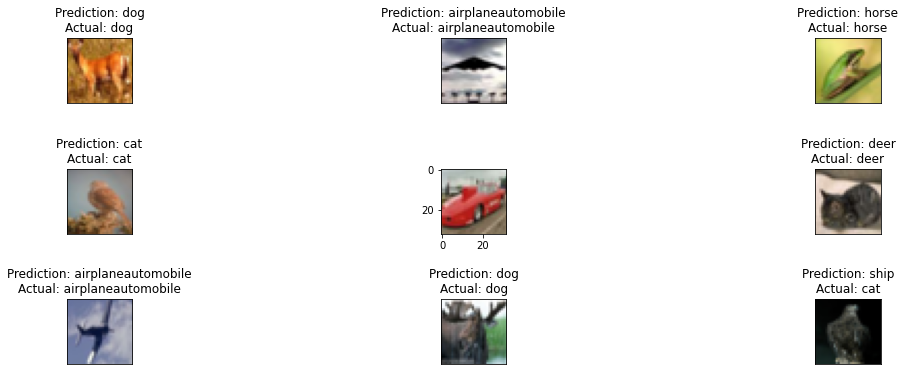

In [42]:
fig, axs=plt.subplots(3, 3, figsize=(19,6))
fig.subplots_adjust(hspace=1)
axs=axs.flatten()


for i, img in enumerate(batch):
  for key, value in class_labels.items():
    if class_result[i] == key: 
      title='Prediction: {}\nActual: {}'.format(class_labels[key], class_labels[labels [i]]) 
      axs[i].set_title(title)
      axs[i].axes.get_xaxis().set_visible(False) 
      axs[i].axes.get_yaxis().set_visible(False)

  #plot the image 
  axs[i].imshow(img)

#show the plot

plt.show()